<a href="https://colab.research.google.com/github/adndrhmdn1/Tasks/blob/main/UTS_PDAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Import Library**

In [ ]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model
from sklearn.ensemble import RandomForestClassifier

# Evaluasi
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Simpan model
import joblib

# **2. Load Dataset**

In [ ]:
train = pd.read_csv('data_training.csv')
test = pd.read_csv('data_testing.csv')

In [ ]:
train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [ ]:
test.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


# **3. Eksplorasi Data**

# Ukuran dataset

In [ ]:
print("Shape Training:", train.shape)
print("Shape Testing:", test.shape)

Shape Training: (857, 13)
Shape Testing: (286, 12)


# Informasi variabel

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


Output ini memberikan informasi mengenai struktur dataset training yang digunakan dalam proses pemodelan klasifikasi kualitas wine. Terdapat 857 sampel data wine yang akan digunakan untuk melatih model klasifikasi dan 11 variabel fitur kimiawi.

# Statistika deskriptif

In [ ]:
train.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


Semua variabel memiliki 857 observasi, yang menunjukkan tidak ada missing value pada dataset training.

Kualitas Wine (quality)
Nilai minimum: 3
Nilai maksimum: 8
Rata-rata: sekitar 5,65
Artinya sebagian besar wine pada dataset berada pada kategori kualitas menengah, yaitu sekitar kualitas 5–6.

Alcohol
Rata-rata kadar alkohol: 10,43
Maksimum: 14
Variabel alcohol memiliki rentang cukup besar dan berpotensi memengaruhi kualitas wine.

Rata-rata Volatile Acidity 0,53. Nilai volatile acidity yang tinggi umumnya dapat menurunkan kualitas wine karena meningkatkan rasa asam berlebih.

Nilai density relatif stabil di sekitar 0,996–0,997, menandakan variasinya kecil.

# **4. Cek Missing Value**

In [ ]:
print(train.isnull().sum())
print(test.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


Tidak terdapat missing value artinya kualitas dataset sangat baik sehingga tidak diperlukan penanganan data hilang seperti imputasi atau penghapusan data.

# **5. Visualisasi Distribusi Quality**

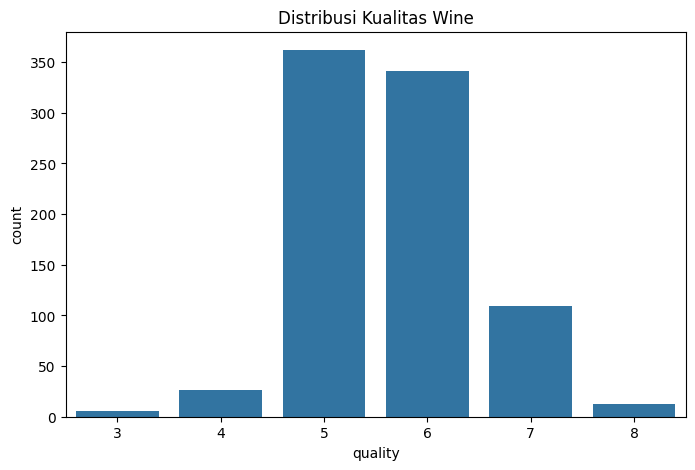

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=train)
plt.title('Distribusi Kualitas Wine')
plt.show()

Grafik ini menunjukkan distribusi jumlah sampel pada masing-masing kelas kualitas wine. Kualitas 5 memiliki jumlah data terbanyak disusul oleh kualitas 6. Kualitas 3, 4, 7, 8 jumlah data lebih sedkit. Artinya dataset mengalami ketidakseimbangan kelas. Karena sebagian besar data berada pada kelas 5 dan 6, model cenderung lebih mudah memprediksi kelas tersebut dibandingkan kelas minoritas.

# **6. Korelasi Antar Variabel**

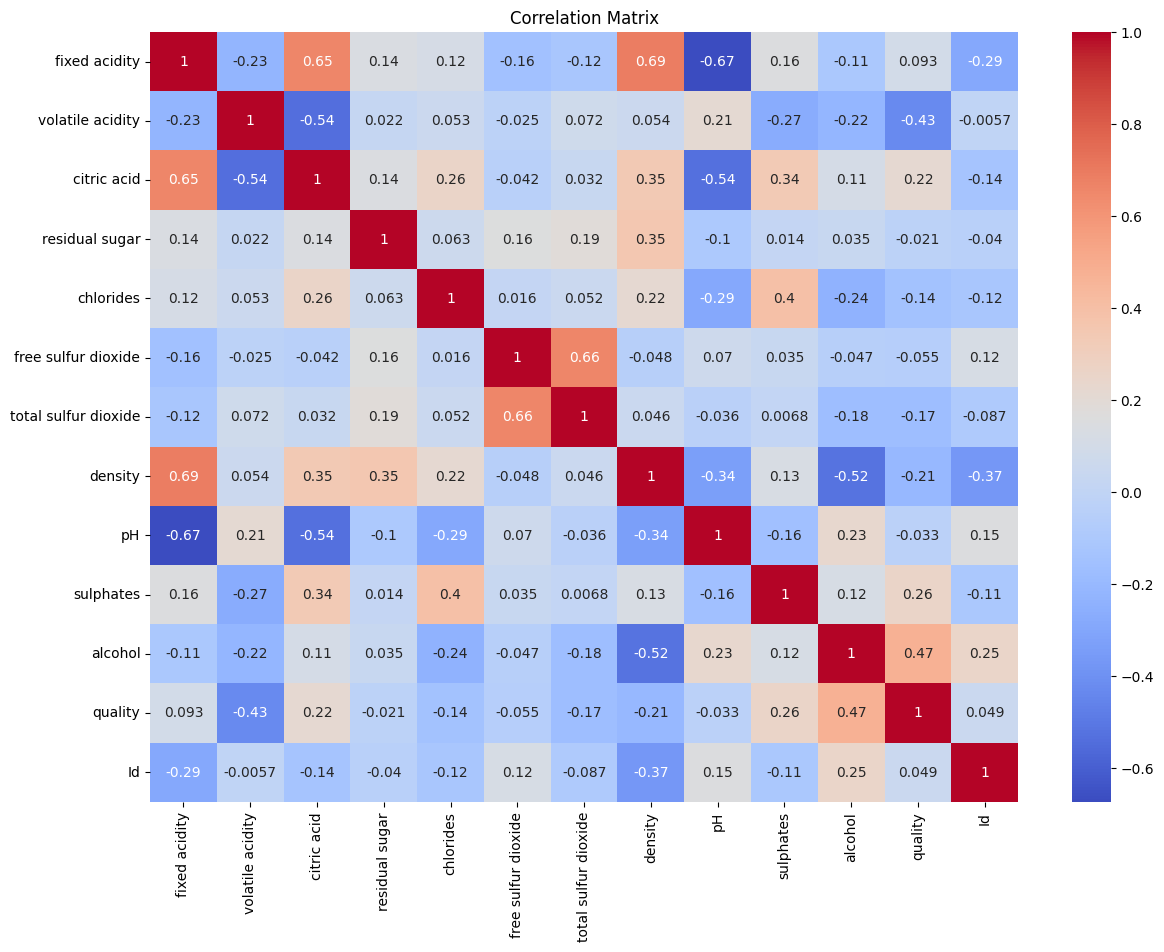

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(train.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Fitur yang paling berpengaruh terhadap kualits dari hasil diatas adalah Alcohol, Volatile Acidity, dan Sulphates.

# **7. Memisahkan Fitur dan Target**

In [ ]:
X = train.drop(['Id', 'quality'], axis=1)
y = train['quality']

# **8. Split Data Training dan Validasi**

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# **9. Feature Scaling**

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# **10. Model Random Forest**

In [ ]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42
)

model.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=15, n_estimators=300, random_state=42)

Konfigurasi ini cukup baik untuk klasifikasi dataset wine karena mampu menangkap pola kompleks tanpa terlalu overfit.

# **11. Evaluasi Model**

# Prediksi validasi

In [ ]:
y_pred = model.predict(X_val_scaled)

# Akurasi

In [ ]:
acc = accuracy_score(y_val, y_pred)
print("Accuracy:", acc)

Accuracy: 0.5930232558139535


Model Random Forest mampu mempelajari pola data kualitas wine dengan performa yang cukup memadai. Meskipun akurasi belum sangat tinggi, model sudah cukup layak digunakan untuk memprediksi kualitas wine pada dataset testing.

# Classification report

In [ ]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.65      0.77      0.70        73
           6       0.54      0.57      0.56        68
           7       0.46      0.27      0.34        22
           8       1.00      0.33      0.50         3

    accuracy                           0.59       172
   macro avg       0.44      0.32      0.35       172
weighted avg       0.57      0.59      0.57       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Berdasarkan classification report, model Random Forest menunjukkan performa yang cukup baik terutama pada kelas kualitas 5 dan 6 yang merupakan kelas dominan dalam dataset. Namun model masih mengalami kesulitan dalam memprediksi kelas minoritas seperti kualitas 3, 4, dan 8 akibat ketidakseimbangan distribusi data. Secara keseluruhan, model cukup layak digunakan untuk prediksi kualitas wine pada data testing, meskipun masih memiliki ruang untuk peningkatan performa.

# Confusion matrix

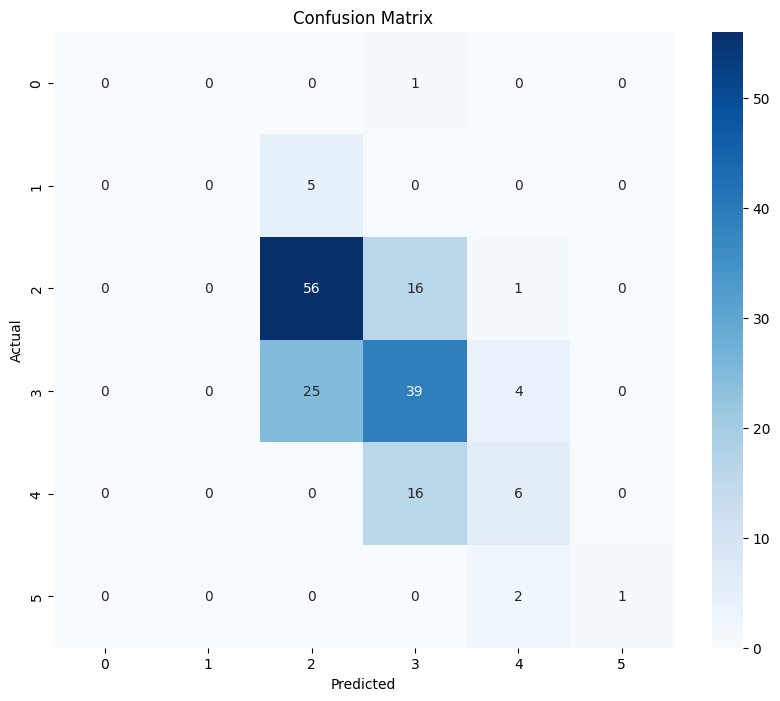

In [ ]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Confusion matrix menunjukkan perbandingan prediksi model dengan label sebenarnya.Pada kualitas 3, 4, 8 jumlah prediksi benar sangat sedikit karena jumlah data latih untuk kelas tersebut terbatas. Model bekerja cukup baik pada kelas mayoritas.

# **12. Menyimpan Model**

In [ ]:
joblib.dump(model, 'wine_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

# **13. Prediksi Data Testing**

# Memisahkan kolom id pada testing

In [ ]:
# Cari kolom ID otomatis
id_col = [col for col in test.columns if col.lower() == 'Id']

if id_col:
    test_id = test[id_col[0]]
    test_features = test.drop(id_col[0], axis=1)
else:
    test_id = range(1, len(test)+1)
    test_features = test.copy()

print("Kolom ID yang digunakan:", id_col if id_col else "ID dibuat otomatis")

Kolom ID yang digunakan: ID dibuat otomatis


In [ ]:
test_id = test['Id']
test_features = test.drop('Id', axis=1)

# Scaling

In [ ]:
test_scaled = scaler.transform(test_features)
predictions = model.predict(test_scaled)

# Prediksi

In [ ]:
predictions = model.predict(test_scaled)

# **15. File Submission**

In [ ]:
submission = pd.DataFrame({
    'id': test_id,
    'quality': predictions
})

In [ ]:
submission.head()

,id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,5


Hasil prediksi menunjukkan bahwa model berhasil menghasilkan klasifikasi kualitas wine untuk data testing. Prediksi yang didominasi kualitas 5 dan 6 konsisten dengan pola distribusi dataset training, sehingga hasil model dapat dianggap logis dan layak digunakan sebagai hasil akhir.

In [ ]:
submission.to_csv('hasilprediksi_048.csv', index=False)

In [ ]:
from google.colab import files
files.download('hasilprediksi_048.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>